In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

In [2]:
with open('/neurospin/dico/driviere/hcp_twin_stats/champollion/best_regions.json', 'r') as f:
    results_nregions = json.load(f)

distance = 'eucl'

# get brain shape values
results_brain_shape_dir = '/neurospin/dico/driviere/hcp_twin_stats/quasi-raw-morpho-closed-bmask/summary.json'
with open(results_brain_shape_dir, 'r') as f:
    res = json.load(f)
    brain_shape_value_1 = res['all']['twin_found'][f'{distance}_MZ'][0]
    brain_shape_value_5 = res['all']['twin_found'][f'{distance}_MZ'][4]

# VBM
results_vbm_dir = None
vbm_value_1 = 0.31
vbm_value_5 = 0.52

# quasi raw ??
results_quasi_raw_dir = '/neurospin/dico/driviere/hcp_twin_stats/quasi-raw-morphologist/summary.json'
with open(results_quasi_raw_dir, 'r') as f:
    res = json.load(f)
    quasi_raw_value_1 = res['all']['twin_found'][f'{distance}_MZ'][0]
    quasi_raw_value_5 = res['all']['twin_found'][f'{distance}_MZ'][4]

curve_MZ_1 = [elem[0] for elem in results_nregions[f'{distance}_MZ']]
curve_MZ_5 = [elem[4] for elem in results_nregions[f'{distance}_MZ']]


with open('/neurospin/dico/driviere/hcp_twin_stats/champollion/summary.json', 'r') as f:
    results = json.load(f)
indiv_perf_MZ_1 = {}
for region in results:
    if region != 'all':
        indiv_perf_MZ_1[region] = results[region]['twin_found'][f'{distance}_MZ'][0]
indiv_perf_MZ_5 = {}
for region in results:
    if region != 'all':
        indiv_perf_MZ_5[region] = results[region]['twin_found'][f'{distance}_MZ'][4]

# rank the regions by MZ performance
df = pd.DataFrame({'region': list(indiv_perf_MZ_1.keys()), 'MZ_1': list(indiv_perf_MZ_1.values()), 'MZ_5': list(indiv_perf_MZ_5.values())})
df = df.sort_values(by='MZ_1', ascending=False).reset_index(drop=True)

In [6]:
herit_table = pd.read_csv('/neurospin/dico/adufournet/2026_Nature/images/globalheritability_table.csv')

In [9]:
m = pd.merge(herit_table, df, left_on='region', right_on='region')
m.corr()

/tmp/ipykernel_269691/2308329194.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  m.corr()


,Loci number Champollion V1,SNP-based h²,se,Region \nvolume,Loci number Morpho,MZ_1,MZ_5
Loci number Champollion V1,1.000000,0.858238,0.723897,0.119125,0.637490,0.683451,0.786931
SNP-based h²,0.858238,1.000000,0.935620,-0.003829,0.623857,0.841256,0.900140
se,0.723897,0.935620,1.000000,-0.057868,0.641416,0.788394,0.840585
Region \nvolume,0.119125,-0.003829,-0.057868,1.000000,0.138002,-0.001248,0.064322
Loci number Morpho,0.637490,0.623857,0.641416,0.138002,1.000000,0.500315,0.538615
MZ_1,0.683451,0.841256,0.788394,-0.001248,0.500315,1.000000,0.902478
MZ_5,0.786931,0.900140,0.840585,0.064322,0.538615,0.902478,1.000000


Text(0.5, 1.0, 'Correlation between SNP-based heritability and MZ_1 performance')

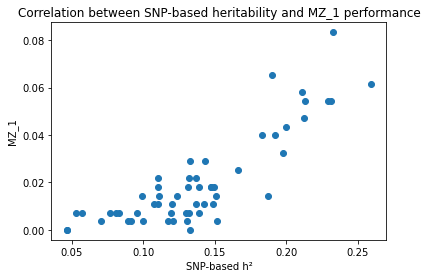

In [10]:
plt.scatter(m['SNP-based h²'], m['MZ_1'])
plt.xlabel('SNP-based h²')
plt.ylabel('MZ_1')
plt.title('Correlation between SNP-based heritability and MZ_1 performance')

Text(0.5, 1.0, 'Correlation between SNP-based heritability and MZ_5 performance')

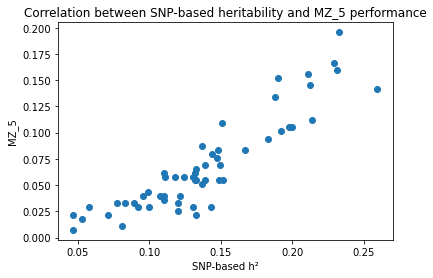

In [12]:
plt.scatter(m['SNP-based h²'], m['MZ_5'])
plt.xlabel('SNP-based h²')
plt.ylabel('MZ_5')
plt.title('Correlation between SNP-based heritability and MZ_5 performance')